## **Title**

In [1]:
# Task 6: House Price Prediction

#Objective:
#Predict house prices using property features such as area and number of bedrooms.
#Evaluate the model using metrics like MAE and RMSE and visualize predictions.

## **Import Libraries**

In [3]:
# Import required libraries
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## **Load Dataset**

In [5]:
# Load house dataset (example CSV: ‘House_Price.csv’)
# Columns: area (sq ft), bedrooms, price

df = pd.read_csv("House_Price.csv")


## **Preview Dataset**

In [6]:
# Preview dataset
print(df.head())
# Shape and column info
print("Shape:", df.shape)
print("Columns:", df.columns)
print("\nDataset info:")
print(df.info())
print("\nDescriptive statistics:")
print(df.describe())

         date     price  bedrooms  grade  has_basement  living_in_m2  \
0  2014-09-26  305000.0         2      1         False      76.18046   
1  2014-05-14  498000.0         3      2          True     210.88981   
2  2015-03-23  590000.0         2      4         False     262.91549   
3  2014-07-15  775000.0         3      3         False     159.79316   
4  2015-04-14  350000.0         2      1         False      92.90300   

   renovated  nice_view  perfect_condition  real_bathrooms  has_lavatory  \
0      False      False               True               1         False   
1      False      False              False               2          True   
2      False      False              False               2          True   
3      False      False              False               1          True   
4      False      False              False               1          True   

   single_floor  month  quartile_zone  
0          True      9              2  
1          True      5        

## **Preprocessing**

In [8]:
# Convert date column (optional)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Drop date (not useful for simple regression)
df = df.drop(columns=['date'])

# Features & Target
X = df.drop(columns=['price'])   # All columns except price
Y = df['price']

## **Train-Test Split**


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

## **Train Model**

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## **Predictions**

In [14]:
Y_pred = model.predict(X_test)

## **Evaluation**

In [18]:
mae = mean_absolute_error(y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(y_test, Y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 78523.1981922916
RMSE: 104279.54744515865


## **Visualization**

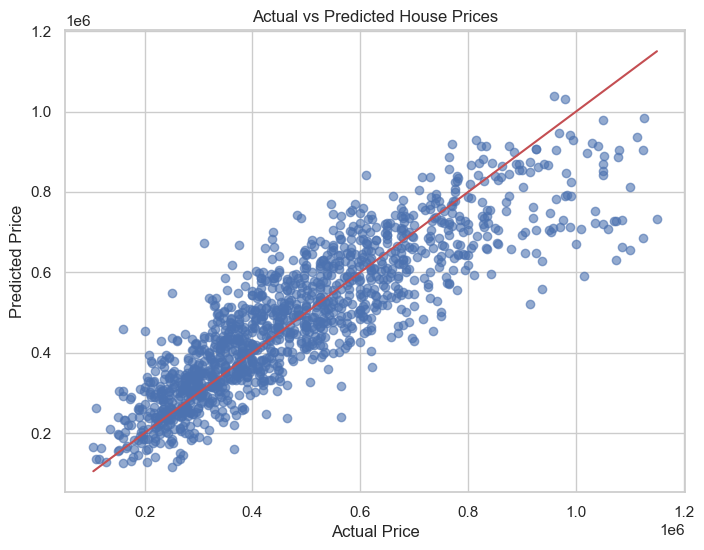

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, Y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

## **Feature Importance**

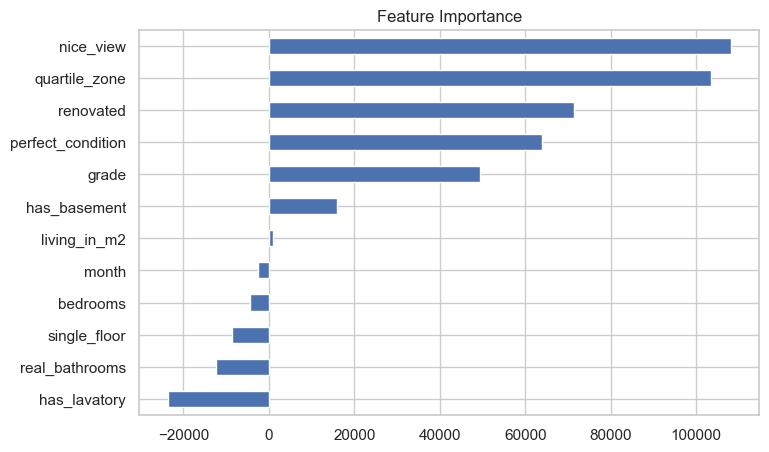

In [22]:
importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Importance")
plt.show()

## **Conclusion**

### Features like living_in_m2 and grade strongly influence house prices.
### Condition and renovation status also affect pricing.
### Model shows reasonable prediction accuracy.
### Adding more features could improve performance.

## **Commitment**

### All work is done by me.
### Dataset is publicly available from Kaggle.
### Code and analysis are original.